<a href="https://colab.research.google.com/github/heoconngoc/Deep_Learning/blob/main/5_Multilayer_Perceptrons.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

### CHAPTER 5. MULTILAYER PERCEPTRONS

The most important thing that distinguish between a Linear Network and a Multilayer Perceptron is the activation function.

Without the activation function, no matter how many layers we have (Linear -> Linear -> Linear), everything is still equivalent to a huge linear function. => Model can not learn complex pattern.

Activation function adds non-linearity characteristic to the model. Hence, model can learn image, language, and more complex parttern.

An activation function should be non-linear, has gradient that is not too small, and can calculate quickly.

In [14]:
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
from torchvision import transforms
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt
import pandas as pd

device = "cuda" if torch.cuda.is_available() else "cpu"

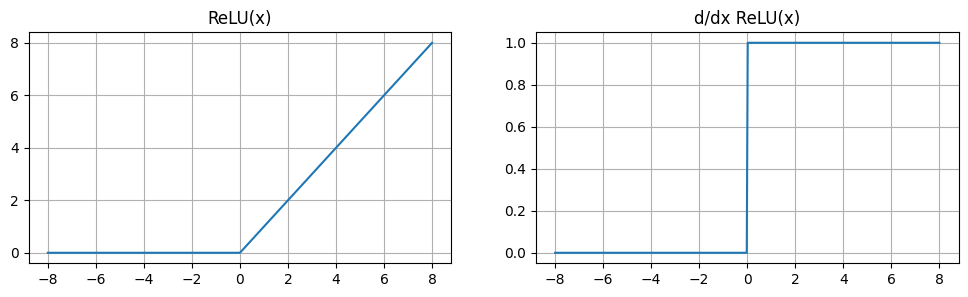

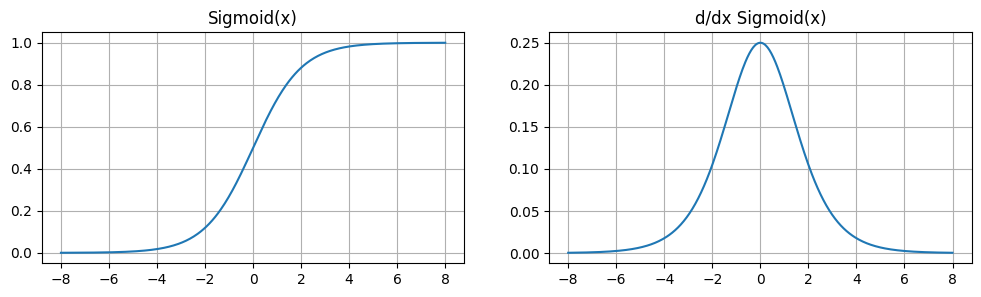

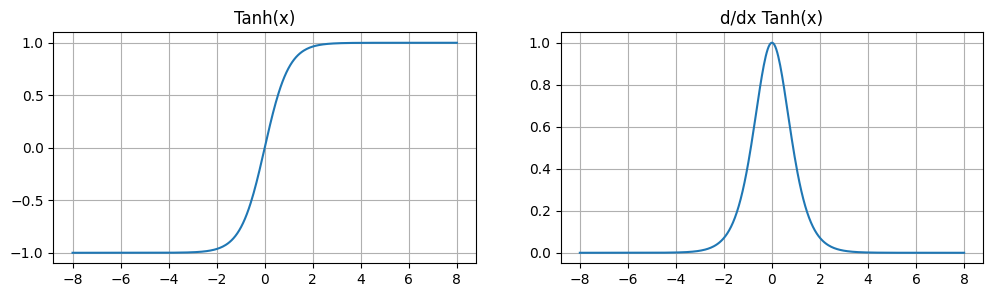

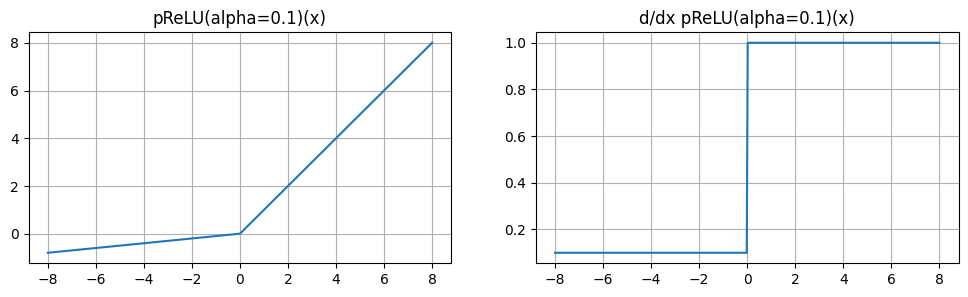

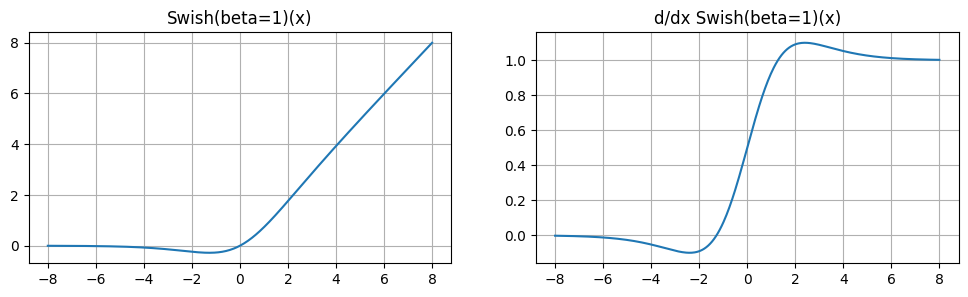

In [9]:
# Plot activation functions + Derivatives (visual)

x = torch.linspace(-8, 8, 400, requires_grad=True) # Create tensor with 400 points between -8 -> 8

def plot_activation(name, y):
    # y: tensor depends on x
    if x.grad is not None:
        x.grad.zero_()
    y.sum().backward(retain_graph=True)
    dy = x.grad.detach().clone()

    plt.figure(figsize=(12,3))
    plt.subplot(1,2,1)
    plt.plot(x.detach(), y.detach())
    plt.title(f"{name}(x)")
    plt.grid(True)

    plt.subplot(1,2,2)
    plt.plot(x.detach(), dy)
    plt.title(f"d/dx {name}(x)")
    plt.grid(True)
    plt.show()

plot_activation("ReLU", torch.relu(x))
plot_activation("Sigmoid", torch.sigmoid(x))
plot_activation("Tanh", torch.tanh(x))

# pReLU with alpha=0.1
alpha = 0.1
prelu = torch.maximum(x, torch.zeros_like(x)) + alpha*torch.minimum(x, torch.zeros_like(x))
plot_activation("pReLU(alpha=0.1)", prelu)

# Swish (beta=1)
beta = 1.0
swish = x * torch.sigmoid(beta*x)
plot_activation("Swish(beta=1)", swish)

### ReLU(x) = max(0, x)
  Negative: Gradient = 0. Neuron turns off totally.

  Positive: Strong gradient, strong learning.

### Sigmoid o(x) = 1 / (1 + e^-x)
  Center: Strong gradient, strong learning.
  
  Others: Gradient is nearly 0. Learning bad.

### Tanh
  Better than sigmoid: Centered around zero
  
  Worse than ReLU in deep network

### pReLU
  Negative: Gradient = alpha. No longer dead in negative like ReLU. Neuron can still learn in negative side.

### Swish
  Has smooth gradient. Better training. Should use in mordern network.

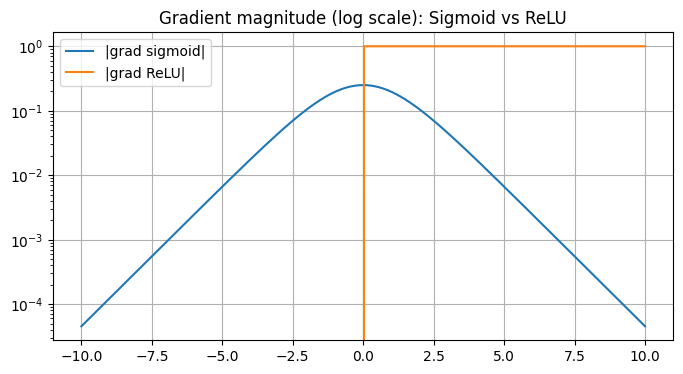

In [10]:
# Vanishing gradient demo (sigmoid vs ReLU)

def grad_magnitude(activation, scale=5.0):
    x = torch.linspace(-scale, scale, 400, requires_grad=True)
    y = activation(x)
    y.sum().backward()
    return x.detach(), x.grad.detach().abs()

xs, g_sig = grad_magnitude(torch.sigmoid, scale=10)
xr, g_relu = grad_magnitude(torch.relu, scale=10)

plt.figure(figsize=(8,4))
plt.plot(xs, g_sig, label="|grad sigmoid|")
plt.plot(xr, g_relu, label="|grad ReLU|")
plt.yscale("log")
plt.title("Gradient magnitude (log scale): Sigmoid vs ReLU")
plt.grid(True)
plt.legend()
plt.show()

From graph above, we can tell that sigmoid has very small gradient when |x| is big => We encounter vanishing gradient problem.

ReLU has gradient 0 or 1 => Gradient is much more stronger, less chance to vanish.

In [11]:
transform = transforms.ToTensor()
train_data = torchvision.datasets.FashionMNIST("./data", train=True, download=True, transform=transform)
test_data  = torchvision.datasets.FashionMNIST("./data", train=False, download=True, transform=transform)

train_loader = DataLoader(train_data, batch_size=256, shuffle=True)
test_loader  = DataLoader(test_data, batch_size=256)

100%|██████████| 26.4M/26.4M [00:01<00:00, 13.9MB/s]
100%|██████████| 29.5k/29.5k [00:00<00:00, 203kB/s]
100%|██████████| 4.42M/4.42M [00:01<00:00, 3.78MB/s]
100%|██████████| 5.15k/5.15k [00:00<00:00, 10.4MB/s]


In [12]:
# Model and training loop

model = nn.Sequential(
    nn.Flatten(),
    nn.Linear(28*28, 256),
    nn.ReLU(),
    nn.Linear(256, 10)
).to(device)

loss_fn = nn.CrossEntropyLoss()  # expects logits, targets as class indices
optimizer = optim.SGD(model.parameters(), lr=0.1)

def evaluate_accuracy(loader):
    model.eval()
    correct, total = 0, 0
    with torch.no_grad():
        for X, y in loader:
            X, y = X.to(device), y.to(device)
            logits = model(X)
            pred = logits.argmax(dim=1)
            correct += (pred == y).sum().item()
            total += y.size(0)
    return correct / total

train_losses, test_accs = [], []

for epoch in range(10):
    model.train()
    total_loss = 0.0
    for X, y in train_loader:
        X, y = X.to(device), y.to(device)
        optimizer.zero_grad()
        logits = model(X)
        loss = loss_fn(logits, y)
        loss.backward()
        optimizer.step()
        total_loss += loss.item()

    acc = evaluate_accuracy(test_loader)
    train_losses.append(total_loss)
    test_accs.append(acc)
    print(f"Epoch {epoch+1}: loss={total_loss:.2f}, test_acc={acc:.4f}")


Epoch 1: loss=203.53, test_acc=0.7884
Epoch 2: loss=130.22, test_acc=0.7810
Epoch 3: loss=116.15, test_acc=0.8152
Epoch 4: loss=108.06, test_acc=0.8121
Epoch 5: loss=102.23, test_acc=0.8440
Epoch 6: loss=98.13, test_acc=0.8346
Epoch 7: loss=94.09, test_acc=0.8501
Epoch 8: loss=91.92, test_acc=0.8130
Epoch 9: loss=89.16, test_acc=0.8563
Epoch 10: loss=87.21, test_acc=0.8476


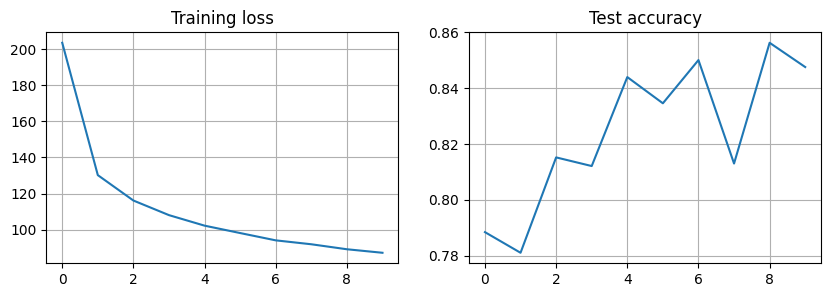

In [13]:
# Visualize training loss and test accuracy

plt.figure(figsize=(10,3))
plt.subplot(1,2,1); plt.plot(train_losses); plt.title("Training loss"); plt.grid(True)
plt.subplot(1,2,2); plt.plot(test_accs); plt.title("Test accuracy"); plt.grid(True)
plt.show()

16 0.8061
32 0.819
64 0.8376
128 0.8422
256 0.8406
512 0.8319
1024 0.8423


,num_hiddens,test_acc
0,16,0.8061
1,32,0.8190
2,64,0.8376
3,128,0.8422
4,256,0.8406
5,512,0.8319
6,1024,0.8423


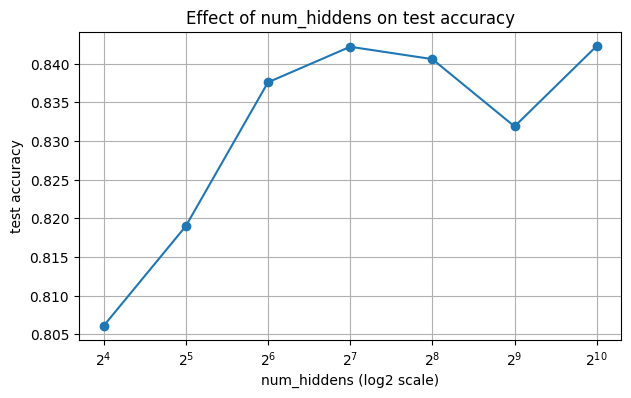

In [15]:
# Sweep num_hiddens + plot accuracy

def train_mlp(num_hiddens=256, lr=0.1, epochs=5):
    model = nn.Sequential(
        nn.Flatten(),
        nn.Linear(28*28, num_hiddens),
        nn.ReLU(),
        nn.Linear(num_hiddens, 10)
    ).to(device)

    loss_fn = nn.CrossEntropyLoss()
    opt = optim.SGD(model.parameters(), lr=lr)

    for _ in range(epochs):
        model.train()
        for X, y in train_loader:
            X, y = X.to(device), y.to(device)
            opt.zero_grad()
            loss = loss_fn(model(X), y)
            loss.backward()
            opt.step()

    # evaluate
    model.eval()
    correct, total = 0, 0
    with torch.no_grad():
        for X, y in test_loader:
            X, y = X.to(device), y.to(device)
            pred = model(X).argmax(dim=1)
            correct += (pred==y).sum().item()
            total += y.size(0)
    return correct/total

hidden_list = [16, 32, 64, 128, 256, 512, 1024]
results = []
for h in hidden_list:
    acc = train_mlp(num_hiddens=h, lr=0.1, epochs=5)
    results.append({"num_hiddens": h, "test_acc": acc})
    print(h, acc)

df = pd.DataFrame(results)
display(df)

plt.figure(figsize=(7,4))
plt.plot(df["num_hiddens"], df["test_acc"], marker="o")
plt.xscale("log", base=2)
plt.title("Effect of num_hiddens on test accuracy")
plt.xlabel("num_hiddens (log2 scale)")
plt.ylabel("test accuracy")
plt.grid(True)
plt.show()


Accuracy improves from 16 → 128 hidden units because the model gains sufficient capacity to reduce underfitting and learn richer nonlinear representations.

Beyond 128, performance largely saturates around ~0.84 with small fluctuations, which is typical when model capacity is no longer the main bottleneck (optimization, regularization, and dataset difficulty dominate).

Very large hidden sizes (e.g., 512) may slightly degrade accuracy due to harder optimization and/or mild overfitting without additional regularization.

A practical sweet spot here is 128 hidden units: similar accuracy to larger models but with fewer parameters and faster training.

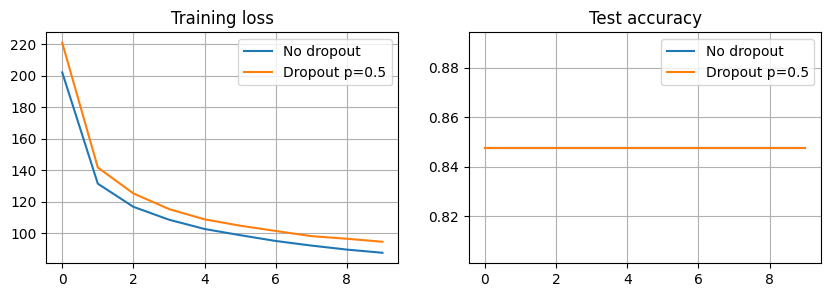

In [16]:
# Dropout experiment

import copy

def train_and_track(dropout_p=0.0, lr=0.1, epochs=10):
    layers = [
        nn.Flatten(),
        nn.Linear(28*28, 256),
        nn.ReLU()
    ]
    if dropout_p > 0:
        layers.append(nn.Dropout(dropout_p))
    layers += [nn.Linear(256, 10)]

    model = nn.Sequential(*layers).to(device)
    loss_fn = nn.CrossEntropyLoss()
    opt = optim.SGD(model.parameters(), lr=lr)

    losses, accs = [], []
    for epoch in range(epochs):
        model.train()
        total_loss = 0
        for X, y in train_loader:
            X, y = X.to(device), y.to(device)
            opt.zero_grad()
            loss = loss_fn(model(X), y)
            loss.backward()
            opt.step()
            total_loss += loss.item()
        losses.append(total_loss)
        accs.append(evaluate_accuracy(test_loader))
    return losses, accs

loss_no, acc_no = train_and_track(dropout_p=0.0, lr=0.1, epochs=10)
loss_do, acc_do = train_and_track(dropout_p=0.5, lr=0.1, epochs=10)

plt.figure(figsize=(10,3))
plt.subplot(1,2,1)
plt.plot(loss_no, label="No dropout")
plt.plot(loss_do, label="Dropout p=0.5")
plt.title("Training loss")
plt.grid(True); plt.legend()

plt.subplot(1,2,2)
plt.plot(acc_no, label="No dropout")
plt.plot(acc_do, label="Dropout p=0.5")
plt.title("Test accuracy")
plt.grid(True); plt.legend()
plt.show()